In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow
import numpy as np
import os

In [2]:
df = pd.read_parquet('df.parquet')

In [3]:
df.shape

(8099023, 64)

In [4]:
for col in df.columns:
    print(col)

Date
AdmissionInstant
AdmitYear
AdmitMonth
AdmitDay
AdmitHour
AdmitMinute
AdmissionSource
AdmissionType
DischargeInstant
DischargeYear
DischargeMonth
DischargeDay
DischargeHour
DischargeMinute
EncounterKey
PatientDurableKey
Type.x
VisitType
VisitTypeDescription
ProviderDurableKey
AttendingProviderDurableKey
DischargeProviderDurableKey
DepartmentKey
PrimaryDiagnosisKey
IsEdVisit
IsHospitalAdmission
IsHospitalOutpatientVisit
IsInpatientAdmission
IsObservation
IsOutpatientFaceToFaceVisit
CensusBlockGroupFipsCode
FirstRace
MaritalStatus
MyChartStatus
OmbEthnicity
OmbRace
SexAssignedAtBirth
SexualOrientation
SmokingStatus
VitalStatus
PatientBirthYearBin
GroupName
GroupCode
DiagnosisName
DiagnosisValue
Address
City
County
DepartmentName
DepartmentSpecialty
DepartmentType
PostalCode
CensusTract
ClinicianTitle
OfficeAddress
OfficeCity
OfficePostalCode
PrimaryDepartment
PrimarySpecialty
Type.y
PopulationValue
CENTLAT
CENTLON


In [5]:
df.head()

,Date,AdmissionInstant,AdmitYear,AdmitMonth,AdmitDay,AdmitHour,AdmitMinute,AdmissionSource,AdmissionType,DischargeInstant,...,ClinicianTitle,OfficeAddress,OfficeCity,OfficePostalCode,PrimaryDepartment,PrimarySpecialty,Type.y,PopulationValue,CENTLAT,CENTLON
0,04/25/22,2022-04-25 20:33:00,2022.0,4.0,25.0,20.0,33.0,Non-Health Care Facility Point of Origin,Elective,2022-04-25 21:35:00,...,MD,634 SW MULVANE STE 209,TOPEKA,66606,*Unspecified,Obstetrics/ Gynecology,Physician,1210.0,39.038987,-95.644925
1,04/29/22,2022-04-29 18:18:00,2022.0,4.0,29.0,18.0,18.0,Clinic/Physician Referral,Elective,2022-04-29 18:20:00,...,MD,800 SW Lincoln,Topeka,66606,SV LINCOLN CENTER,Obstetrics/ Gynecology,Physician,890.0,39.053098,-95.720976
2,01/10/22,2022-01-10 05:52:00,2022.0,1.0,10.0,5.0,52.0,Non-Health Care Facility Point of Origin,Elective,2022-01-12 11:43:00,...,MD,NaN,NaN,NaN,*Unspecified,Obstetrics/ Gynecology,Physician,NaN,NaN,NaN
3,03/08/22,2022-03-08 09:08:00,2022.0,3.0,8.0,9.0,8.0,Non-Health Care Facility Point of Origin,Elective,2022-03-10 13:45:00,...,CNM,800 SW Lincoln,Topeka,66606,SV LINCOLN CENTER,Obstetrics/ Gynecology,Midwife,1687.0,39.023433,-95.660754
4,03/16/22,2022-03-16 14:19:00,2022.0,3.0,16.0,14.0,19.0,Non-Health Care Facility Point of Origin,Elective,2022-03-16 16:00:00,...,MD,NaN,NaN,NaN,*Unspecified,Obstetrics/ Gynecology,Physician,NaN,NaN,NaN


In [6]:
patient_col = "PatientDurableKey"      
encounter_col = "EncounterKey"        
date_col = "Date"                     
specialty_col = "DepartmentSpecialty"  
department_col = "PrimaryDepartment"      
provider_col = "ProviderDurableKey"          
diagnosis_col = "DiagnosisValue" 
diagnosis_name_col = "DiagnosisName"      
type_col = "Type.x"

In [7]:
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df_clean = df.dropna(subset=[patient_col, date_col]).copy()

C:\Users\larry\AppData\Local\Temp\ipykernel_36720\4229589101.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce")


In [8]:
df_clean.shape

(8099023, 64)

In [9]:
patient_summary = (
    df_clean
    .groupby(patient_col)
    .agg(
        n_rows=(patient_col, "size"),
        n_diagnosis_names=("DiagnosisName", "nunique"),
        n_encounters=(encounter_col, "nunique"),
        first_date=(date_col, "min"),
        last_date=(date_col, "max"),
        n_specialties=(specialty_col, "nunique"),
        n_departments=(department_col, "nunique"),
        n_providers=(provider_col, "nunique"),
        n_diagnoses=(diagnosis_col, "nunique"),
        n_visit_types=(type_col, "nunique")
    )
    .reset_index()
)

patient_summary["care_span_days"] = (
    patient_summary["last_date"] - patient_summary["first_date"]
).dt.days

patient_summary.head()

,PatientDurableKey,n_rows,n_diagnosis_names,n_encounters,first_date,last_date,n_specialties,n_departments,n_providers,n_diagnoses,n_visit_types,care_span_days
0,5.0,13,8,11,2025-07-02,2025-11-06,6,6,6,8,4,127
1,9.0,7,4,7,2024-04-04,2024-11-04,3,4,5,4,4,214
2,17.0,33,9,33,2022-04-12,2025-08-26,5,7,11,9,4,1232
3,19.0,1,1,1,2022-02-14,2022-02-14,1,1,1,1,1,0
4,33.0,12,6,12,2022-06-16,2025-12-22,4,3,5,6,6,1285


In [10]:
def specialty_buckets(x):
    if x <= 0:
        return "0 specialties"
    elif x == 1:
        return "1 specialty"
    elif x <= 3:
        return "2-3 specialties"
    elif x <= 5:
        return "4-5 specialties"
    elif x <= 7:
        return "6-7 specialties"
    else:
        return "8+ specialties"
    
patient_summary["specialty_bucket"] = patient_summary["n_specialties"].apply(specialty_buckets)

<Axes: xlabel='specialty_bucket'>

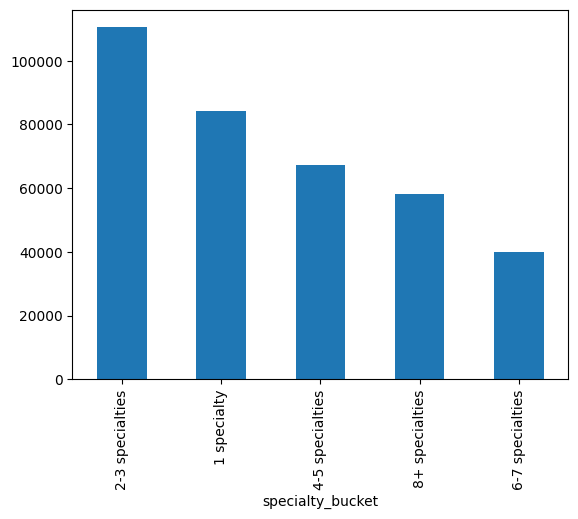

In [11]:
patient_summary["specialty_bucket"].value_counts().plot(kind="bar")

In [12]:
patient_summary['n_encounters'].max()

patient_summary[patient_summary['n_encounters'] == patient_summary['n_encounters'].max()][['PatientDurableKey', 'n_encounters']]


,PatientDurableKey,n_encounters
240988,7136932.0,1287


In [13]:
df[df["PatientDurableKey"] == 7136932.0][['CENTLON', 'CENTLAT']]


,CENTLON,CENTLAT
23141,-95.715753,39.112739
104513,-95.715753,39.112739
113394,-95.715753,39.112739
118520,-95.715753,39.112739
120413,-95.715753,39.112739
...,...,...
8055370,-95.715753,39.112739
8065708,-95.715753,39.112739
8076921,-95.715753,39.112739
8081461,-95.715753,39.112739


In [14]:
bucket_summary = (
    patient_summary
    .groupby("specialty_bucket")
    .agg(
        patients=(patient_col, "nunique"),
        median_encounters=("n_encounters", "median"),
        mean_encounters=("n_encounters", "mean"),
        median_care_span=("care_span_days", "median"),
        mean_care_span=("care_span_days", "mean"),
        median_departments=("n_departments", "median"),
        median_providers=("n_providers", "median"),
        median_diagnoses=("n_diagnoses", "median")
    )
    .reset_index()
)

bucket_order = ["1 specialty", "2-3 specialties", "4-5 specialties", "6-7 specialties", "8+ specialties"]
bucket_summary["specialty_bucket"] = pd.Categorical(
    bucket_summary["specialty_bucket"],
    categories=bucket_order,
    ordered=True
)

bucket_summary = bucket_summary.sort_values("specialty_bucket")
bucket_summary

,specialty_bucket,patients,median_encounters,mean_encounters,median_care_span,mean_care_span,median_departments,median_providers,median_diagnoses
0,1 specialty,84061,1.0,1.976957,0.0,136.260930,1.0,1.0,1.0
1,2-3 specialties,110514,5.0,6.681769,432.0,527.369103,3.0,3.0,3.0
2,4-5 specialties,67119,14.0,16.440933,970.0,868.493601,5.0,7.0,7.0
3,6-7 specialties,39955,25.0,29.042348,1163.0,1024.902340,8.0,11.0,11.0
4,8+ specialties,58111,60.0,77.563645,1340.0,1205.599577,15.0,23.0,21.0


In [15]:
df_clean["encounter_date"] = df_clean[date_col].dt.date

daily_counts = (
    df_clean
    .groupby([patient_col, "encounter_date"])
    .agg(daily_encounters=(encounter_col, "nunique"))
    .reset_index()
)

burst_summary = (
    daily_counts
    .groupby(patient_col)
    .agg(
        max_same_day_encounters=("daily_encounters", "max"),
        days_with_2plus_encounters=("daily_encounters", lambda x: (x >= 2).sum())
    )
    .reset_index()
)

patient_summary = patient_summary.merge(burst_summary, on=patient_col, how="left")

patient_summary["max_same_day_encounters"] = patient_summary["max_same_day_encounters"].fillna(0)
patient_summary["days_with_2plus_encounters"] = patient_summary["days_with_2plus_encounters"].fillna(0)

In [16]:
df["diagnosis_prefix"] = df["DiagnosisValue"].astype(str).str[:3]

In [37]:
from sklearn.preprocessing import StandardScaler

score_cols = [
    "n_specialties",
    "n_departments",
    "n_providers",
    "n_diagnoses",
    "n_visit_types"
]

score_data = patient_summary[score_cols].fillna(0)

scaler = StandardScaler()
z = scaler.fit_transform(score_data)
patient_summary["fragmentation_score"] = z.mean(axis=1)

In [40]:
patient_summary["fragmentation_group"] = pd.qcut(
    patient_summary["fragmentation_score"],
    q=4,
    labels=["Low", "Medium-low", "Medium-high", "High"])

patient_summary[[
    patient_col,
    "fragmentation_score",
    "fragmentation_group",
    "n_encounters",
    "care_span_days"
]].head()

,PatientDurableKey,fragmentation_score,fragmentation_group,n_encounters,care_span_days
0,5.0,0.055232,Medium-high,11,127
1,9.0,-0.276544,Medium-high,7,214
2,17.0,0.145951,Medium-high,33,1232
3,19.0,-0.844800,Low,1,0
4,33.0,-0.065757,Medium-high,12,1285


In [65]:
radar_cols = [
    "n_specialties",
    "n_departments",
    "n_providers",
    "n_diagnoses",
    "n_visit_types"
]

radar_labels = [
    "Specialties",
    "Departments",
    "Providers",
    "Diagnoses",
    "Visit types"
]

# Median raw values by fragmentation group
radar_raw = (
    patient_summary
    .groupby("fragmentation_group")[radar_cols]
    .median()
    .loc[["Low", "Medium-low", "Medium-high", "High"]]
)

radar_log = np.log1p(radar_raw)
radar_log

,n_specialties,n_departments,n_providers,n_diagnoses,n_visit_types
fragmentation_group,,,,,
Low,0.693147,0.693147,0.693147,0.693147,0.693147
Medium-low,1.098612,1.386294,1.386294,1.386294,1.386294
Medium-high,1.609438,1.791759,2.079442,1.945910,1.609438
High,2.197225,2.564949,2.944439,2.890372,2.079442


In [67]:
radar_scaled = radar_log / radar_log.max(axis=0)
radar_scaled

,n_specialties,n_departments,n_providers,n_diagnoses,n_visit_types
fragmentation_group,,,,,
Low,0.315465,0.270238,0.235409,0.239812,0.333333
Medium-low,0.500000,0.540476,0.470818,0.479625,0.666667
Medium-high,0.732487,0.698555,0.706227,0.673239,0.773976
High,1.000000,1.000000,1.000000,1.000000,1.000000


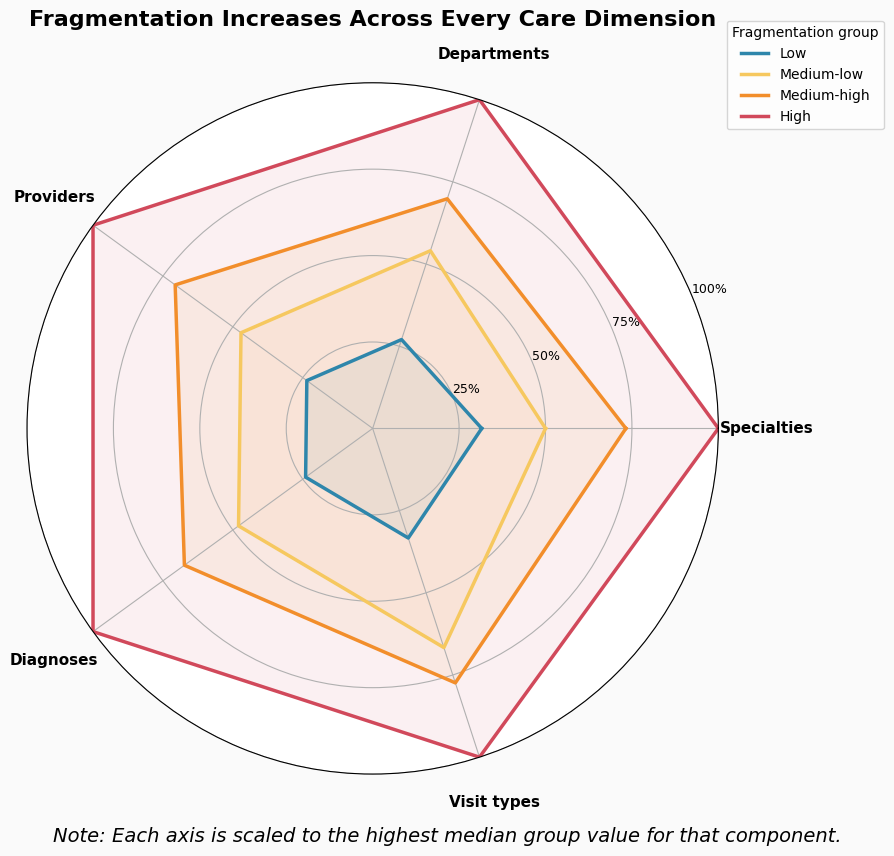

,n_specialties,n_departments,n_providers,n_diagnoses,n_visit_types
fragmentation_group,,,,,
Low,1.0,1.0,1.0,1.0,1.0
Medium-low,2.0,3.0,3.0,3.0,3.0
Medium-high,4.0,5.0,7.0,6.0,4.0
High,8.0,12.0,18.0,17.0,7.0


In [100]:
categories = radar_labels
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), facecolor='#fafafa', subplot_kw=dict(polar=True))


group_order = ["Low", "Medium-low", "Medium-high", "High"]

colors = {
    "Low": "#2E86AB",          # blue
    "Medium-low": "#F6C85F",   # yellow
    "Medium-high": "#F28E2B",  # orange
    "High": "#D1495B"          # red
}

for group in group_order:
    values = radar_scaled.loc[group].tolist()
    values += values[:1]
    
    ax.plot(
        angles,
        values,
        linewidth=2.5,
        label=group,
        color=colors[group]
    )
    
    ax.fill(
        angles,
        values,
        alpha=0.08,
        color=colors[group]
    )

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight="bold")
ax.tick_params(axis="x", pad=24)

# Radial labels
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=9)
ax.set_ylim(0, 1)

ax.set_title(
    "Fragmentation Increases Across Every Care Dimension",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.10),
    title="Fragmentation group"
)

fig.text(
    0.5, 0.02,
    "Note: Each axis is scaled to the highest median group value for that component.",
    ha="center",
    fontsize=14,
    style="italic"
)

plt.tight_layout()
plt.savefig("fragmentation_score_radar.png", dpi=300, bbox_inches="tight")
plt.show()

radar_raw_rounded = radar_raw.round(1)
radar_raw_rounded

In [41]:
df_graph = df_clean.merge(
    patient_summary[[patient_col, "fragmentation_group", "fragmentation_score"]],
    on=patient_col,
    how="left"
)

df_graph["fragmentation_group"] = df_graph["fragmentation_group"].astype(str)
df_graph[specialty_col] = df_graph[specialty_col].astype(str)
df_graph[type_col] = df_graph[type_col].astype(str)

df_graph.shape

(8099023, 67)

In [79]:
graph_base = df_graph.dropna(
    subset=["fragmentation_group", specialty_col, type_col]
).copy()

# Remove useless string-like missing values
graph_base = graph_base[
    ~graph_base[specialty_col].isin(["nan", "None", "", "*Unspecified"])
].copy()

graph_base = graph_base[
    ~graph_base[type_col].isin(["nan", "None", ""])
].copy()

# Keep only top categories so the graph is not a hairball
top_specialties = graph_base[specialty_col].value_counts().head(10).index
top_visit_types = graph_base[type_col].value_counts().head(10).index

graph_small = graph_base[
    graph_base[specialty_col].isin(top_specialties) &
    graph_base[type_col].isin(top_visit_types)
].copy()

In [80]:
# Patient segment -> specialty edges
edges_segment_specialty = (
    graph_small
    .groupby(["fragmentation_group", specialty_col])
    .agg(weight=(encounter_col, "nunique"))
    .reset_index()
)

edges_segment_specialty.columns = ["segment", "specialty", "weight"]

# Specialty -> visit type edges
edges_specialty_type = (
    graph_small
    .groupby([specialty_col, type_col])
    .agg(weight=(encounter_col, "nunique"))
    .reset_index()
)

edges_specialty_type.columns = ["specialty", "visit_type", "weight"]

# Keep only strongest specialty -> visit type links
edges_specialty_type = (
    edges_specialty_type
    .sort_values("weight", ascending=False)
    .head(40)
    .copy()
)

edges_segment_specialty.head(), edges_specialty_type.head()

(  segment          specialty  weight
 0    High         Cardiology  135458
 1    High    Care Management  257783
 2    High    Family Medicine  334046
 3    High  Internal Medicine  181712
 4    High                Lab  888421,
           specialty        visit_type   weight
 25              Lab         Lab Visit  1051361
 46        Radiology           Imaging   514125
 12  Family Medicine      Office Visit   509146
 44        Radiology       Appointment   430281
 7   Care Management  Patient Outreach   322245)

In [81]:
from neo4j import GraphDatabase

NEO4J_URI = "neo4j+ssc://57629caa.databases.neo4j.io"
NEO4J_USER = "57629caa"
NEO4J_PASSWORD = "Bu18W7XI3FW53hVlp3Q7mvqP_u8kqbnWinADcRTW1gE"

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD)

)

def connect_to_aura():
    # The 'neo4j+s://' scheme ensures an encrypted connection required by Aura
    with GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD)) as driver:
    
        driver.verify_connectivity()
        print("Successfully connected to Neo4j Aura!")

if __name__ == "__main__":
    connect_to_aura()


Successfully connected to Neo4j Aura!


In [83]:
def run_query(q, params=None):
    with driver.session() as session:
        result = session.run(q, params or {})
        return [record.data() for record in result]

In [84]:
run_query("""
CREATE CONSTRAINT patient_segment_name IF NOT EXISTS
FOR (n:PatientSegment)
REQUIRE n.name IS UNIQUE
""")

run_query("""
CREATE CONSTRAINT specialty_name IF NOT EXISTS
FOR (n:Specialty)
REQUIRE n.name IS UNIQUE
""")

run_query("""
CREATE CONSTRAINT visit_type_name IF NOT EXISTS
FOR (n:VisitType)
REQUIRE n.name IS UNIQUE
""")

[]

In [85]:
rows = edges_segment_specialty.to_dict("records")

run_query(
    """
    UNWIND $rows AS row
    MERGE (seg:PatientSegment {name: row.segment})
    MERGE (spec:Specialty {name: row.specialty})
    MERGE (seg)-[r:TOUCHED]->(spec)
    SET r.weight = toInteger(row.weight)
    """,
    {"rows": rows}
)

[]

In [86]:
rows = edges_specialty_type.to_dict("records")

run_query(
    """
    UNWIND $rows AS row
    MERGE (spec:Specialty {name: row.specialty})
    MERGE (visit:VisitType {name: row.visit_type})
    MERGE (spec)-[r:USES]->(visit)
    SET r.weight = toInteger(row.weight)
    """,
    {"rows": rows}
)

[]

In [87]:
pd.DataFrame(run_query("""
MATCH (n)
RETURN labels(n) AS label, count(*) AS count
ORDER BY count DESC
"""))

,label,count
0,[Specialty],10
1,[VisitType],10
2,[PatientSegment],4


In [88]:
pd.DataFrame(run_query("""
MATCH ()-[r]->()
RETURN type(r) AS relationship, count(*) AS count
ORDER BY count DESC
"""))

,relationship,count
0,USES,40
1,TOUCHED,40


In [89]:
pd.DataFrame(run_query("""
MATCH ()-[r]->()
RETURN type(r) AS relationship, count(*) AS count
ORDER BY count DESC
"""))

,relationship,count
0,USES,40
1,TOUCHED,40


In [90]:
neo_edges = pd.DataFrame(run_query("""
MATCH (a)-[r]->(b)
RETURN 
    a.name AS source,
    labels(a)[0] AS source_type,
    type(r) AS relationship,
    b.name AS target,
    labels(b)[0] AS target_type,
    r.weight AS weight
"""))

neo_edges.head()

,source,source_type,relationship,target,target_type,weight
0,Cardiology,Specialty,USES,Initial consult,VisitType,14906
1,Cardiology,Specialty,USES,Follow-Up,VisitType,678
2,Cardiology,Specialty,USES,Imaging,VisitType,2607
3,Cardiology,Specialty,USES,Office Visit,VisitType,151297
4,Cardiology,Specialty,USES,Appointment,VisitType,2111


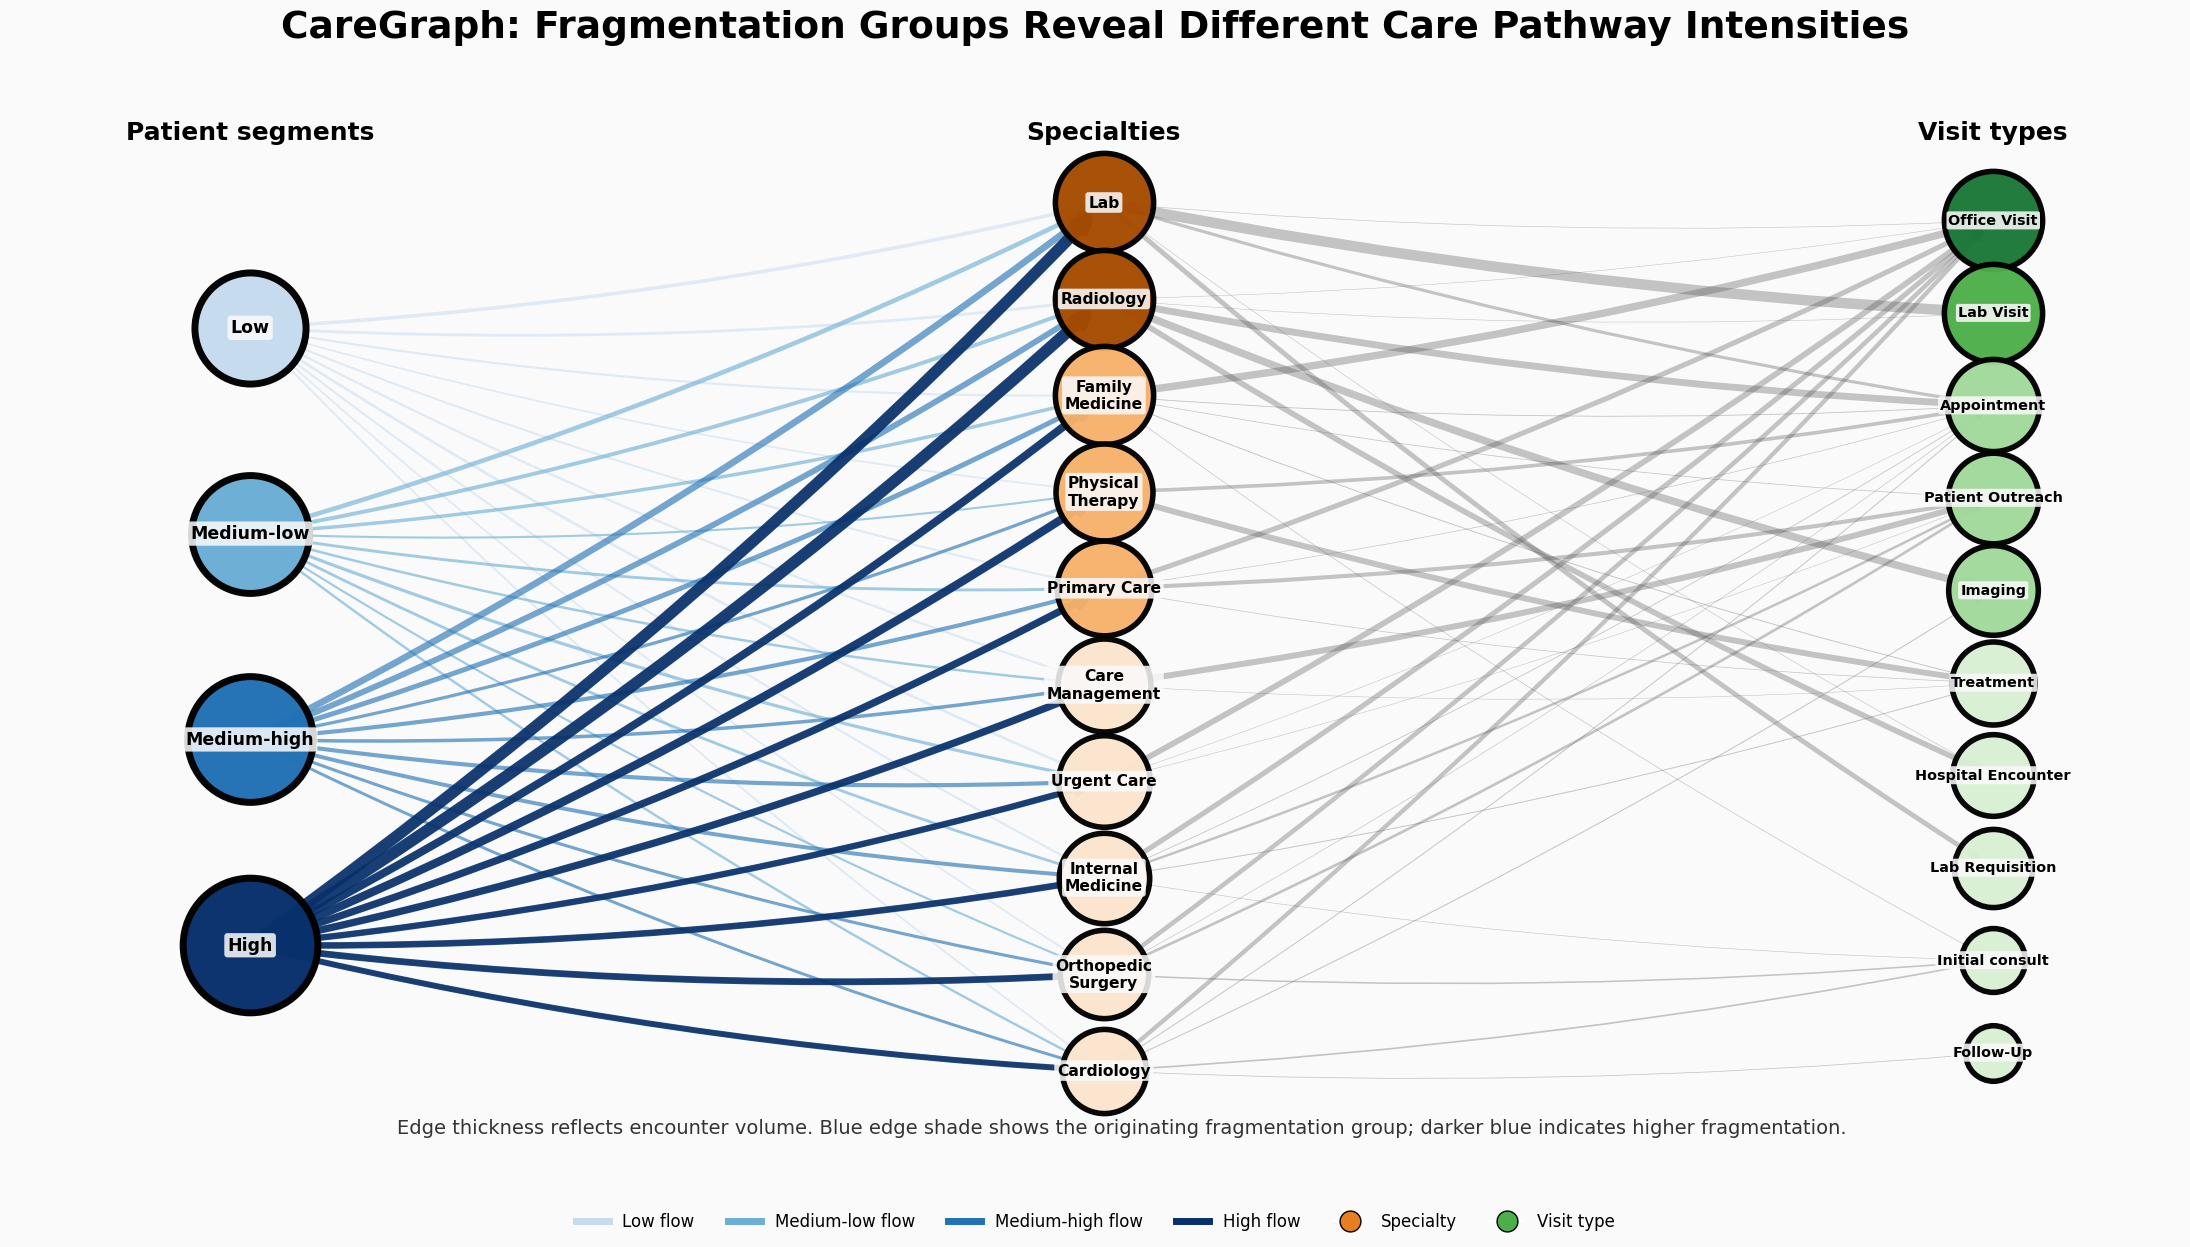

In [118]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import textwrap

# -------------------------------------------------------
# Build NetworkX graph from Neo4j query result
# -------------------------------------------------------

G = nx.DiGraph()

for _, row in neo_edges.iterrows():
    G.add_node(row["source"], node_type=row["source_type"])
    G.add_node(row["target"], node_type=row["target_type"])
    G.add_edge(
        row["source"],
        row["target"],
        weight=row["weight"],
        relationship=row["relationship"]
    )

# -------------------------------------------------------
# Manual layered layout
# -------------------------------------------------------

segments = [n for n, d in G.nodes(data=True) if d["node_type"] == "PatientSegment"]
specialties = [n for n, d in G.nodes(data=True) if d["node_type"] == "Specialty"]
visit_types = [n for n, d in G.nodes(data=True) if d["node_type"] == "VisitType"]

segment_order = ["Low", "Medium-low", "Medium-high", "High"]
segments = [s for s in segment_order if s in segments]

def weighted_degree(node):
    total = 0
    for u, v in G.in_edges(node):
        total += G[u][v]["weight"]
    for u, v in G.out_edges(node):
        total += G[u][v]["weight"]
    return total

specialties = sorted(specialties, key=weighted_degree, reverse=True)
visit_types = sorted(visit_types, key=weighted_degree, reverse=True)

pos = {}

# More spacing to reduce overlap
segment_y = np.linspace(3.45, -3.45, len(segments))
for node, y in zip(segments, segment_y):
    pos[node] = (0, y)

specialty_y = np.linspace(4.85, -4.85, len(specialties))
for node, y in zip(specialties, specialty_y):
    pos[node] = (4.8, y)

visit_y = np.linspace(4.65, -4.65, len(visit_types))
for node, y in zip(visit_types, visit_y):
    pos[node] = (9.8, y)

# -------------------------------------------------------
# Node sizes and colors
# -------------------------------------------------------

weights = nx.get_edge_attributes(G, "weight")
max_weight = max(weights.values())

node_sizes = {}
for node in G.nodes():
    total = weighted_degree(node)
    scaled = np.sqrt(total / max_weight)
    node_sizes[node] = 1500 + 3800 * scaled

# Cap specialty/visit nodes so they don't overlap too much
for node in specialties:
    node_sizes[node] = min(node_sizes[node], 5000)

for node in visit_types:
    node_sizes[node] = min(node_sizes[node], 5000)

# Bigger patient segment nodes
segment_size_map = {
    "Low": 6400,
    "Medium-low": 7200,
    "Medium-high": 8200,
    "High": 9400
}

for node in segments:
    node_sizes[node] = segment_size_map.get(node, 7000)

# Segment colors: blue gradient
segment_colors = {
    "Low": "#C6DBEF",
    "Medium-low": "#6BAED6",
    "Medium-high": "#2171B5",
    "High": "#08306B"
}

# Specialty colors: orange gradient by volume
specialty_degrees = {node: weighted_degree(node) for node in specialties}
max_specialty_degree = max(specialty_degrees.values()) if specialty_degrees else 1

specialty_colors = {}
for node in specialties:
    intensity = specialty_degrees[node] / max_specialty_degree
    if intensity > 0.75:
        specialty_colors[node] = "#A64B00"
    elif intensity > 0.50:
        specialty_colors[node] = "#E67E22"
    elif intensity > 0.25:
        specialty_colors[node] = "#F6B26B"
    else:
        specialty_colors[node] = "#FCE5CD"

# Visit type colors: green gradient by volume
visit_degrees = {node: weighted_degree(node) for node in visit_types}
max_visit_degree = max(visit_degrees.values()) if visit_degrees else 1

visit_colors = {}
for node in visit_types:
    intensity = visit_degrees[node] / max_visit_degree
    if intensity > 0.75:
        visit_colors[node] = "#1B7837"
    elif intensity > 0.50:
        visit_colors[node] = "#4DAF4A"
    elif intensity > 0.25:
        visit_colors[node] = "#A1D99B"
    else:
        visit_colors[node] = "#D9F0D3"

# -------------------------------------------------------
# Edge groups
# -------------------------------------------------------

segment_edges = [(u, v) for u, v in G.edges() if u in segments]

specialty_visit_edges = [
    (u, v) for u, v in G.edges()
    if G.nodes[u]["node_type"] == "Specialty" and G.nodes[v]["node_type"] == "VisitType"
]

# Widths based on edge weight
edge_widths = {
    (u, v): 0.35 + 7.2 * np.sqrt(G[u][v]["weight"] / max_weight)
    for u, v in G.edges()
}

# Segment edge color by originating fragmentation group
def segment_edge_color(u):
    return segment_colors.get(u, "#777777")

# -------------------------------------------------------
# Draw figure
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(22, 12.5))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")

# Draw specialty -> visit type edges first: gray but visible
nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edgelist=specialty_visit_edges,
    width=[edge_widths[e] for e in specialty_visit_edges],
    alpha=0.34,
    arrows=True,
    arrowsize=12,
    edge_color="#595959",
    connectionstyle="arc3,rad=0.035"
)

# Draw patient segment -> specialty edges BY SEGMENT COLOR
for seg in segments:
    seg_edges = [(u, v) for u, v in segment_edges if u == seg]
    
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=seg_edges,
        width=[edge_widths[e] + 0.7 for e in seg_edges],
        alpha=0.62 if seg != "Low" else 0.50,
        arrows=True,
        arrowsize=14,
        edge_color=segment_colors[seg],
        connectionstyle="arc3,rad=0.045"
    )

# Optional: draw High one more time on top for emphasis, not annotation
high_edges = [(u, v) for u, v in segment_edges if u == "High"]

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    edgelist=high_edges,
    width=[edge_widths[e] + 1.4 for e in high_edges],
    alpha=0.82,
    arrows=True,
    arrowsize=17,
    edge_color=segment_colors["High"],
    connectionstyle="arc3,rad=0.045"
)

# -------------------------------------------------------
# Draw nodes
# -------------------------------------------------------

# Patient segment nodes
for node in segments:
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=[node],
        node_size=node_sizes[node],
        node_color=segment_colors.get(node, "#4C78A8"),
        edgecolors="black",
        linewidths=5,
        alpha=0.98
    )

# Specialty nodes
for node in specialties:
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=[node],
        node_size=node_sizes[node],
        node_color=specialty_colors[node],
        edgecolors="black",
        linewidths=4,
        alpha=0.97
    )

# Visit type nodes
for node in visit_types:
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        nodelist=[node],
        node_size=node_sizes[node],
        node_color=visit_colors[node],
        edgecolors="black",
        linewidths=4,
        alpha=0.97
    )

# -------------------------------------------------------
# Labels
# -------------------------------------------------------

segment_labels = {}
specialty_labels = {}
visit_labels = {}

for node in segments:
    segment_labels[node] = str(node)

for node in specialties:
    # Wrap only longer specialty names
    specialty_labels[node] = "\n".join(textwrap.wrap(str(node), width=14))

for node in visit_types:
    # Keep visit type labels on one line
    visit_labels[node] = str(node)

# Patient segment labels
nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    labels=segment_labels,
    font_size=12.5,
    font_weight="bold",
    font_color="black",
    bbox=dict(
        facecolor="#fafafa",
        edgecolor="none",
        alpha=0.86,
        boxstyle="round,pad=0.18"
    )
)

# Specialty labels
nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    labels=specialty_labels,
    font_size=11.2,
    font_weight="bold",
    font_color="black",
    bbox=dict(
        facecolor="#fafafa",
        edgecolor="none",
        alpha=0.86,
        boxstyle="round,pad=0.18"
    )
)

# Visit type labels: slightly smaller, no wrapping
nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    labels=visit_labels,
    font_size=10.4,
    font_weight="bold",
    font_color="black",
    bbox=dict(
        facecolor="#fafafa",
        edgecolor="none",
        alpha=0.86,
        boxstyle="round,pad=0.14"
    )
)
# -------------------------------------------------------
# Titles, headers, caption
# -------------------------------------------------------

ax.set_title(
    "CareGraph: Fragmentation Groups Reveal Different Care Pathway Intensities",
    fontsize=27,
    fontweight="bold",
    pad=48
)

header_y = 5.55
ax.text(0, header_y, "Patient segments", ha="center", fontsize=18, fontweight="bold")
ax.text(4.8, header_y, "Specialties", ha="center", fontsize=18, fontweight="bold")
ax.text(9.8, header_y, "Visit types", ha="center", fontsize=18, fontweight="bold")

ax.text(
    4.9,
    -5.55,
    "Edge thickness reflects encounter volume. Blue edge shade shows the originating fragmentation group; darker blue indicates higher fragmentation.",
    ha="center",
    fontsize=14,
    color="#333333"
)

# Legend
legend_elements = [
    Line2D([0], [0], color=segment_colors["Low"], lw=5, label="Low flow"),
    Line2D([0], [0], color=segment_colors["Medium-low"], lw=5, label="Medium-low flow"),
    Line2D([0], [0], color=segment_colors["Medium-high"], lw=5, label="Medium-high flow"),
    Line2D([0], [0], color=segment_colors["High"], lw=5, label="High flow"),
    Line2D(
        [0], [0], marker="o", color="w", label="Specialty",
        markerfacecolor="#E67E22", markeredgecolor="black", markersize=15
    ),
    Line2D(
        [0], [0], marker="o", color="w", label="Visit type",
        markerfacecolor="#4DAF4A", markeredgecolor="black", markersize=15
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.09),
    ncol=6,
    frameon=False,
    fontsize=12
)

ax.set_xlim(-1.35, 10.85)
ax.set_ylim(-5.75, 5.95)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "neo4j.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#fafafa"
)
plt.show()